# Do the suburbs pay their way? — Fiscal Productivity of Austin-Metro Land

Tests the Strong Towns hypothesis that low-density development doesn't generate enough value (hence
tax) per acre to cover the infrastructure it occupies, so the dense core cross-subsidizes it.

**Method (land/acre break-even).** Infrastructure cost scales with *land area* (linear feet of road &
pipe), revenue with *value*. If cost-to-serve is ~uniform per serviced acre, the break-even per acre =
total tax levy / total acres = the **average tax-per-acre**. Then:

- `revenue        = market_value * effective_tax_rate`
- `tax_per_acre    = revenue / land_acres`
- `breakeven       = sum(revenue) / sum(land_acres)`  *(uniform cost-per-acre)*
- `net_per_acre    = tax_per_acre - breakeven`   → **>0 pays its way (subsidizes); <0 net drain (subsidized)**

**Two lenses** (the result depends on what land counts as 'serviced' — this *is* the key finding):
1. **All land** — includes rural/ag tracts. Break-even is low; the drain shows up as *rural sprawl*.
2. **Developed only** (parcels ≤ `DEVELOPED_ACRE_MAX` acres) — the fair city-vs-suburb test. Break-even
   is higher; low-density *developed* suburbs fall below it.

**Coverage.** Full three-county metro at ~2025 vintage: **Travis** = TCAD GIS parcel geometry joined to
the **2025 certified appraisal roll** (Supp 330) by `PROP_ID` — every city incl. Lakeway, Pflugerville,
Bee Cave, West Lake Hills; **Williamson + Hays** = their CAD ArcGIS FeatureServers (current cycle). See
the Data Provenance & Vintage section below. Tax rate is a blended ~2.1% approximation (rates vary by
jurisdiction); since a uniform rate cancels in `net`, the *relative* pattern is robust — absolute
dollars are first-order.

## Setup

In [1]:
import sys, math, urllib.request, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import folium
import h3
import branca.colormap as bcm

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
OUT_DIR = REPO_ROOT / 'outputs'; OUT_DIR.mkdir(exist_ok=True)
PROC = REPO_ROOT / 'processed_data'
METRO_PARQUET = PROC / 'parcels_value_per_acre_metro.parquet'
PLACES_ZIP = PROC / 'tx_places.zip'
HWY_GEOJSON = PROC / 'metro_highways.geojson'
print('ready')

ready


## Config

In [2]:
EFFECTIVE_TAX_RATE = 0.021   # blended city+county+school+special (~2.1%)
DEVELOPED_ACRE_MAX = 5.0     # 'developed' = parcels at or below this acreage (excludes rural/ag)
MIN_CITY_PARCELS = 500       # only report cities with at least this many covered parcels
H3_RES = 8                   # hex resolution for the fiscal-productivity map
MAX_ABS_NET = None           # color clip for net/acre map; None = auto (robust p95 of |net|)

## Load parcels + city labels

In [3]:
g = gpd.read_parquet(METRO_PARQUET)
g['revenue'] = g['market_value'] * EFFECTIVE_TAX_RATE
g['tax_per_acre'] = g['revenue'] / g['land_acres']

# city label via spatial join to Census incorporated places (parcel centroid within place)
if not PLACES_ZIP.exists():
    urllib.request.urlretrieve('https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_48_place_500k.zip', PLACES_ZIP)
places = gpd.read_file(PLACES_ZIP)[['NAME', 'geometry']].to_crs('EPSG:4326')
cent = g.to_crs(2277).geometry.centroid.to_crs(4326)
g['lon'] = cent.x.values; g['lat'] = cent.y.values
pts = gpd.GeoDataFrame(g[['revenue', 'land_acres', 'market_value', 'value_per_acre']].copy(),
                       geometry=cent, crs='EPSG:4326')
g['city'] = gpd.sjoin(pts, places, how='left', predicate='within')['NAME'].fillna('Unincorporated').values
print(f'{len(g):,} parcels across {g["county"].nunique()} counties; '
      f'{g["city"].nunique()} place labels')

724,639 parcels across 3 counties; 61 place labels


## The two-lens break-even
`net_dollars` per parcel = revenue − breakeven × acres. Summed over an area it gives that area's annual
surplus (+) or deficit (−) under the uniform-cost-per-acre assumption.

In [4]:
def fiscal(df):
    be = df['revenue'].sum() / df['land_acres'].sum()
    out = df.copy()
    out['net_dollars'] = out['revenue'] - be * out['land_acres']
    return out, be

all_land, be_all = fiscal(g)
developed, be_dev = fiscal(g[g['land_acres'] <= DEVELOPED_ACRE_MAX])
print(f'break-even (all land)       = ${be_all:,.0f}/acre/yr')
print(f'break-even (developed only) = ${be_dev:,.0f}/acre/yr')
print(f'total levy modeled          = ${g["revenue"].sum()/1e9:.2f}B/yr')

break-even (all land)       = $8,421/acre/yr
break-even (developed only) = $30,781/acre/yr
total levy modeled          = $12.56B/yr


## Density gradient — net per acre across value-per-acre deciles

,decile,parcels,acres,med_vpa,net_M,net_per_acre
0,0,72464,"1,161,633","$61,949","$-8,858M","$-7,626"
1,1,72464,"126,586","$376,363",$-138M,"$-1,087"
2,2,72464,"58,729","$1,027,442",$+704M,"$+11,992"
3,3,72464,"27,308","$1,646,288",$+700M,"$+25,619"
4,4,72464,"20,609","$1,992,785",$+687M,"$+33,320"
5,5,72463,"20,904","$2,286,501",$+825M,"$+39,489"
6,6,72464,"17,656","$2,586,567",$+812M,"$+45,971"
7,7,72464,"17,934","$2,947,990",$+961M,"$+53,589"
8,8,72464,"18,574","$3,477,232","$+1,213M","$+65,331"
9,9,72464,"21,052","$5,129,958","$+3,094M","$+146,965"


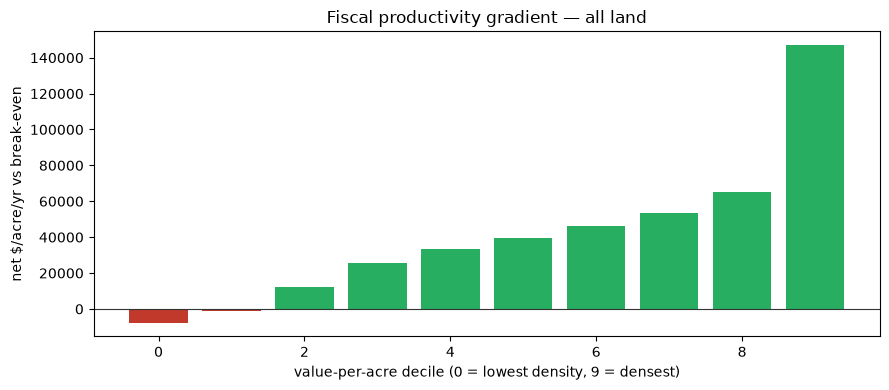

In [5]:
g_all, _ = fiscal(g)
g_all['decile'] = pd.qcut(g_all['value_per_acre'], 10, labels=False, duplicates='drop')
grad = g_all.groupby('decile').agg(parcels=('net_dollars','size'), acres=('land_acres','sum'),
        med_vpa=('value_per_acre','median'), net_M=('net_dollars', lambda s: s.sum()/1e6)).reset_index()
grad['net_per_acre'] = grad['net_M']*1e6 / grad['acres']
display(grad.style.format({'med_vpa':'${:,.0f}', 'net_M':'${:+,.0f}M', 'acres':'{:,.0f}',
                           'net_per_acre':'${:+,.0f}'}))
fig, ax = plt.subplots(figsize=(9,4))
colors = ['#c0392b' if v < 0 else '#27ae60' for v in grad['net_per_acre']]
ax.bar(grad['decile'], grad['net_per_acre'], color=colors)
ax.axhline(0, color='#333', lw=0.8)
ax.set_xlabel('value-per-acre decile (0 = lowest density, 9 = densest)')
ax.set_ylabel('net $/acre/yr vs break-even')
ax.set_title('Fiscal productivity gradient — all land')
plt.tight_layout(); plt.savefig(OUT_DIR/'fiscal_gradient.png', dpi=110); plt.show()

## Per-city surplus / deficit (developed-land lens — the fair city-vs-suburb test)

,city,parcels,acres,rev_M,net_M,med_vpa,net_per_acre
16,Garfield,560,802,$2M,$-22M,"$97,533","$-27,680"
1,Bartlett,647,258,$2M,$-6M,"$347,887","$-23,794"
34,Mustang Ridge,543,369,$3M,$-9M,"$411,251","$-23,648"
43,Serenada,642,762,$7M,$-16M,"$471,515","$-21,165"
59,Wimberley,1287,"1,963",$20M,$-41M,"$589,582","$-20,629"
15,Florence,518,272,$3M,$-5M,"$498,609","$-19,634"
18,Granger,742,230,$3M,$-4M,"$567,872","$-18,705"
24,Jonestown,2411,"2,057",$26M,$-38M,"$640,347","$-18,268"
26,Lago Vista,12559,"4,670",$58M,$-85M,"$262,613","$-18,260"
53,Unincorporated,173147,"125,840","$1,848M","$-2,026M","$1,658,307","$-16,098"


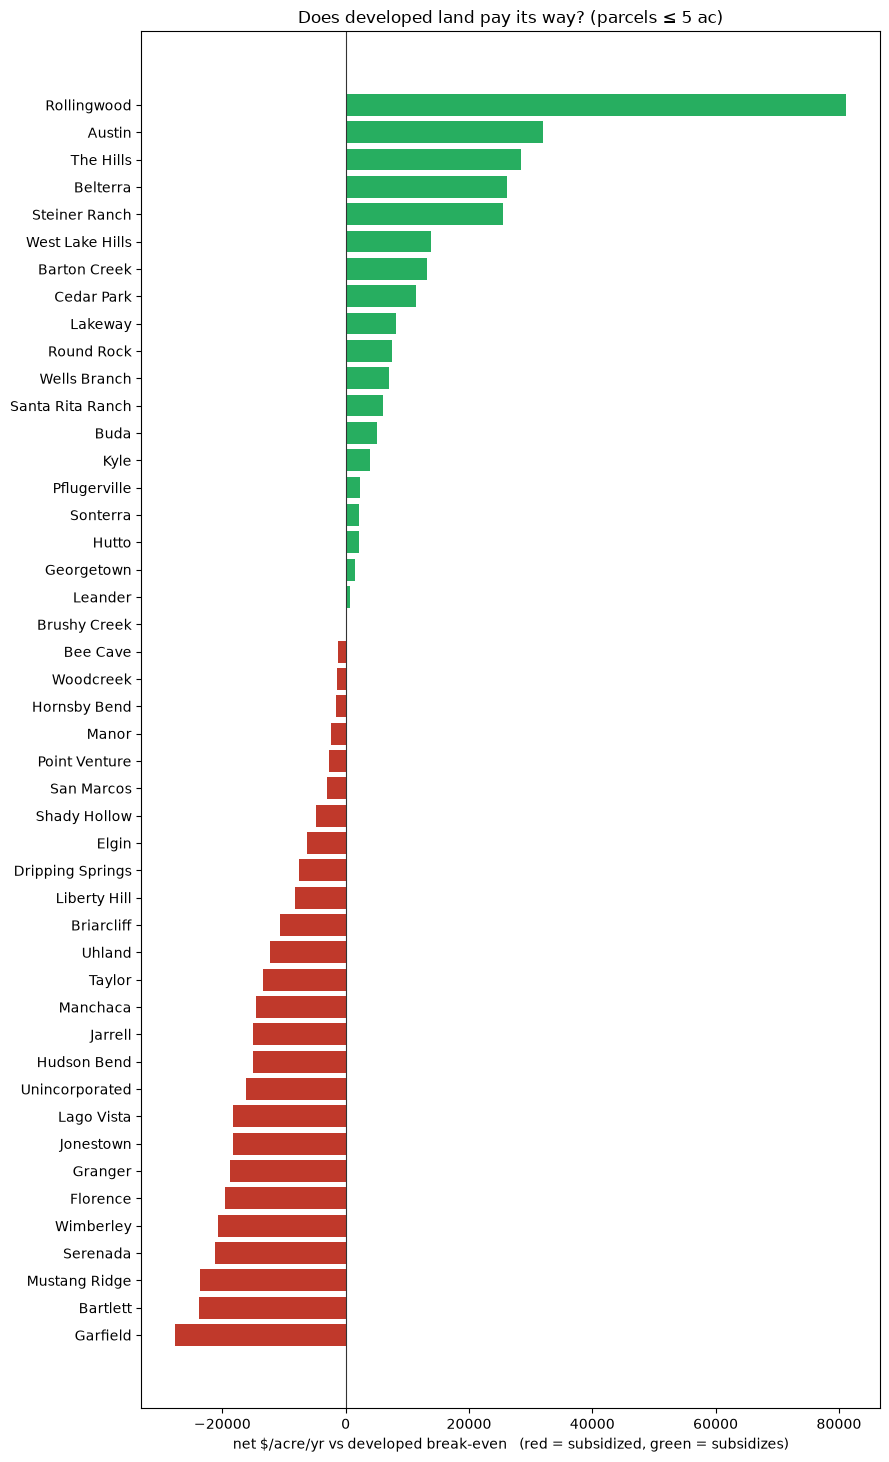

In [6]:
def by_city(df, be):
    d = df.assign(net_dollars=df['revenue'] - be*df['land_acres'])
    c = d.groupby('city').agg(parcels=('net_dollars','size'), acres=('land_acres','sum'),
        rev_M=('revenue', lambda s:s.sum()/1e6), net_M=('net_dollars', lambda s:s.sum()/1e6),
        med_vpa=('value_per_acre','median')).reset_index()
    c['net_per_acre'] = c['net_M']*1e6 / c['acres']
    return c[c['parcels'] >= MIN_CITY_PARCELS].sort_values('net_per_acre')

dev = g[g['land_acres'] <= DEVELOPED_ACRE_MAX]
city_dev = by_city(dev, be_dev)
display(city_dev.style.format({'rev_M':'${:,.0f}M', 'net_M':'${:+,.0f}M', 'med_vpa':'${:,.0f}',
                               'acres':'{:,.0f}', 'net_per_acre':'${:+,.0f}'}))

fig, ax = plt.subplots(figsize=(9, max(4, 0.32*len(city_dev))))
colors = ['#c0392b' if v < 0 else '#27ae60' for v in city_dev['net_per_acre']]
ax.barh(city_dev['city'], city_dev['net_per_acre'], color=colors)
ax.axvline(0, color='#333', lw=0.8)
ax.set_xlabel('net $/acre/yr vs developed break-even   (red = subsidized, green = subsidizes)')
ax.set_title(f'Does developed land pay its way? (parcels ≤ {DEVELOPED_ACRE_MAX:g} ac)')
plt.tight_layout(); plt.savefig(OUT_DIR/'fiscal_by_city.png', dpi=110); plt.show()

## Fiscal-productivity map — does this land pay for itself?
H3 hexes colored by `net_per_acre` (diverging): **red = net drain** (below break-even, subsidized),
**green = surplus** (above break-even, subsidizes the rest). Major highways overlaid for orientation.

In [7]:
agg = pd.DataFrame({'hex': [h3.latlng_to_cell(la, lo, H3_RES) for la, lo in zip(g['lat'], g['lon'])],
                    'revenue': g['revenue'].values, 'land_acres': g['land_acres'].values})
hx = agg.groupby('hex').agg(revenue=('revenue','sum'), land_acres=('land_acres','sum'),
                            n=('hex','size')).reset_index()
hx['net_per_acre'] = hx['revenue']/hx['land_acres'] - be_all
clip = MAX_ABS_NET or float(np.percentile(np.abs(hx['net_per_acre']), 95))
cmap = bcm.LinearColormap(['#b2182b', '#ef8a62', '#f7f7f7', '#67a9cf', '#2166ac'],
    vmin=-clip, vmax=clip, caption=f'net $/acre/yr vs break-even (${be_all:,.0f}/acre)')
def col(v): return cmap(max(-clip, min(clip, v)))
clat, clon = float(g['lat'].mean()), float(g['lon'].mean())
m = folium.Map(location=[clat, clon], zoom_start=10, tiles='CartoDB positron')
for _, r in hx.iterrows():
    folium.Polygon([[a, b] for a, b in h3.cell_to_boundary(r['hex'])], color='#888', weight=0.2,
        fill=True, fill_color=col(r['net_per_acre']), fill_opacity=0.72,
        tooltip=f"net ${r['net_per_acre']:+,.0f}/acre · {int(r['n'])} parcels").add_to(m)
if HWY_GEOJSON.exists():
    hwy = gpd.read_file(HWY_GEOJSON)
    hwy['geometry'] = hwy.to_crs(2277).geometry.simplify(150).to_crs(4326)
    gj = hwy.to_json()
    folium.GeoJson(gj, style_function=lambda f: {'color':'#fff','weight':4,'opacity':0.9}).add_to(m)
    folium.GeoJson(gj, style_function=lambda f: {'color':'#222','weight':1.6,'opacity':0.95}).add_to(m)
cmap.add_to(m)
out = OUT_DIR / 'map_fiscal_productivity.html'; m.save(str(out)); print('wrote', out)

wrote /Users/chaseeasterling/GitHub/fire-incident-analysis/outputs/map_fiscal_productivity.html


## Cost model B — real infrastructure burden (road-miles)

The land/acre model assumes cost-to-serve is uniform per acre. A truer proxy is the **local road
network** each area actually requires — Strong Towns' *value-per-road-mile*. We load TIGER roads,
exclude state-maintained interstates/primary highways (`MTFCC S1100`), measure local road-miles per
area, and recompute net with **cost ∝ road-miles** (calibrated so the developed metro breaks even).
This rewards areas that generate lots of value per mile of pavement and penalizes road-heavy,
low-value development — regardless of acreage.

In [8]:
FIPS = ['48453', '48491', '48209']  # Travis, Williamson, Hays
TIGER = 'https://www2.census.gov/geo/tiger/TIGER2023/ROADS/tl_2023_{}_roads.zip'
rd = []
for f in FIPS:
    p = PROC / f'roads_{f}.zip'
    if not p.exists():
        urllib.request.urlretrieve(TIGER.format(f), p)
    rd.append(gpd.read_file(p))
roads = gpd.GeoDataFrame(pd.concat(rd, ignore_index=True), crs='EPSG:4269').to_crs(4326)
local = roads[~roads['MTFCC'].isin(['S1100'])].copy()      # drop state-maintained interstates/primary
local['mi'] = local.to_crs(2277).geometry.length / 5280.0
rpts = gpd.GeoDataFrame(local[['mi']].copy(), geometry=local.geometry.representative_point(), crs=4326)
print(f'{len(local):,} local road segments, {local["mi"].sum():,.0f} local road-miles')

41,464 local road segments, 14,234 local road-miles


### Per-city: land-cost vs road-cost (does the verdict change?)

road cost-to-serve = $626,957 per local-road-mile/yr (break-even)
11 cities change verdict between models: ['Bee Cave', 'Buda', 'Elgin', 'Georgetown', 'Kyle', 'Liberty Hill', 'Manor', 'Point Venture', 'Shady Hollow', 'Wells Branch', 'Woodcreek']
wrote /Users/chaseeasterling/GitHub/fire-incident-analysis/outputs/city_fiscal_verdicts.csv (46 cities)


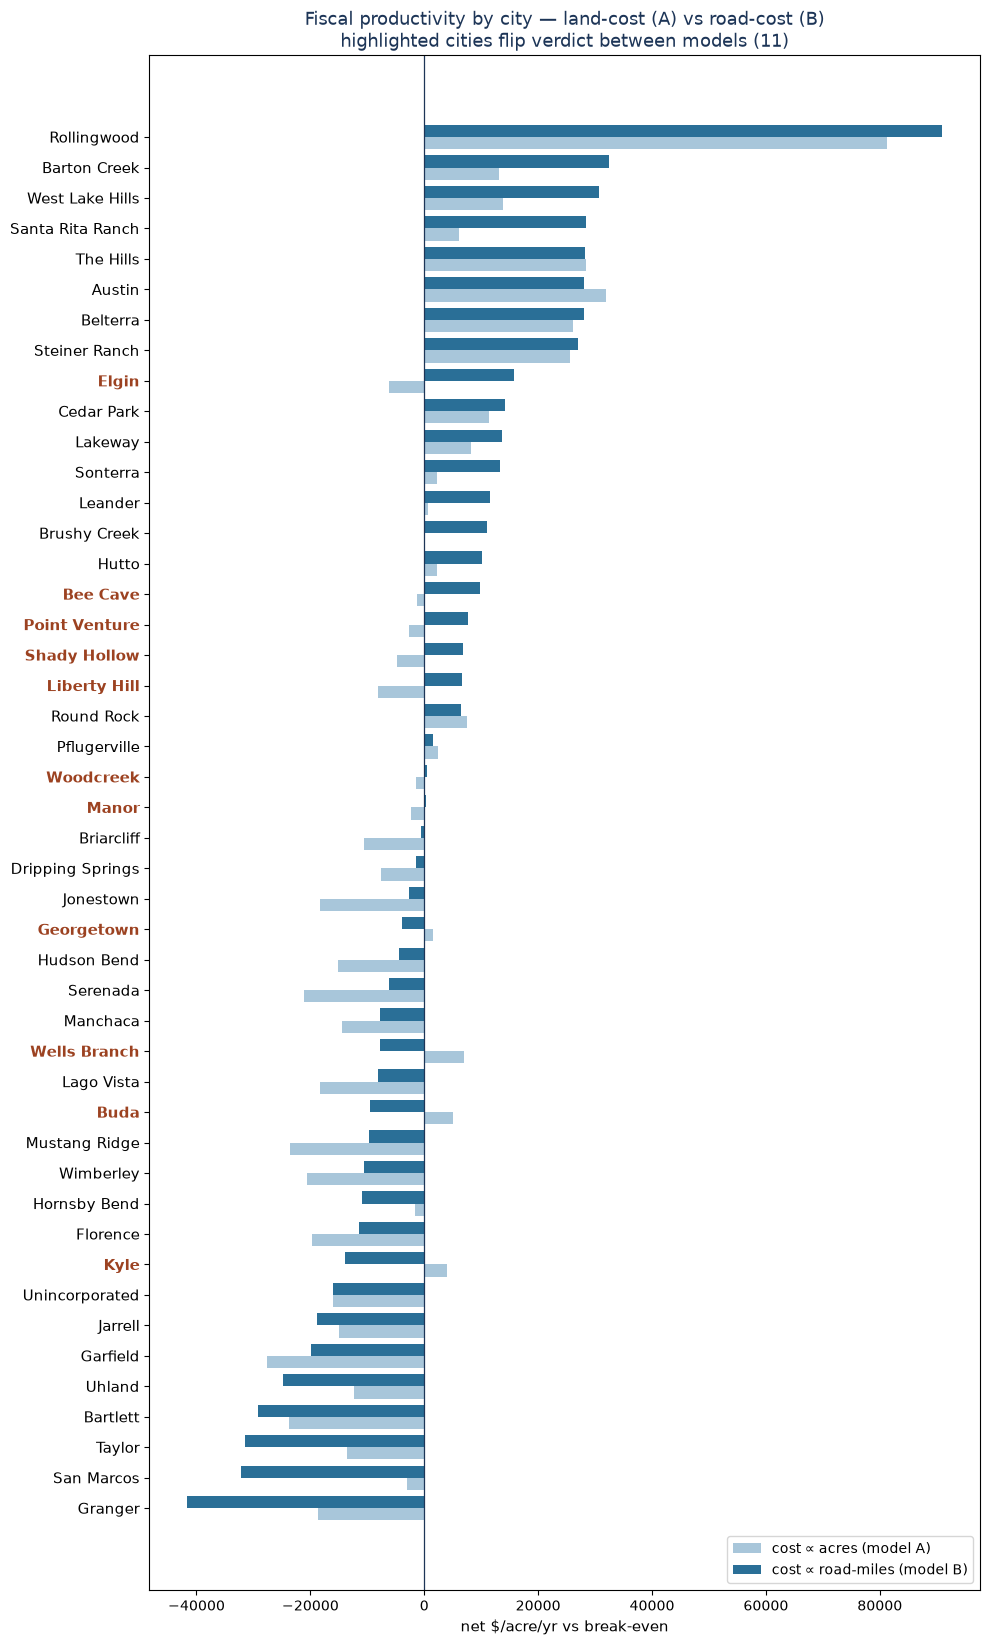

In [9]:
rj = gpd.sjoin(rpts, places, how='left', predicate='within'); rj['NAME'] = rj['NAME'].fillna('Unincorporated')
road_mi = rj.groupby('NAME')['mi'].sum()
dv = dev.groupby('city').agg(revenue=('revenue','sum'), acres=('land_acres','sum'), parcels=('revenue','size'))
dv['road_mi'] = road_mi.reindex(dv.index).fillna(0)
dv = dv[dv['parcels'] >= MIN_CITY_PARCELS]
cost_per_mi = dv['revenue'].sum() / dv['road_mi'].sum()
dv['net_land'] = (dv['revenue'] - be_dev * dv['acres']) / dv['acres']
dv['net_road'] = (dv['revenue'] - cost_per_mi * dv['road_mi']) / dv['acres']
print(f'road cost-to-serve = ${cost_per_mi:,.0f} per local-road-mile/yr (break-even)')
flips = dv[(dv['net_land'] > 0) != (dv['net_road'] > 0)]
print(f'{len(flips)} cities change verdict between models:', sorted(flips.index.tolist()))

# Export per-city verdicts + median home values so the report's §6.2 table is
# reproducible from committed code (median = residential-sized parcels, 0.05–1.5 ac).
homes = g[g['land_acres'].between(0.05, 1.5)]
dv['median_home_value'] = homes.groupby('city')['market_value'].median().reindex(dv.index)
def _verdict(r):
    a, b = r['net_land'] > 0, r['net_road'] > 0
    if a != b:
        return 'flips to contributor' if b else 'flips to net drain'
    return 'contributor under both' if a else 'net drain under both'
dv['verdict'] = dv.apply(_verdict, axis=1)
dv.sort_values('net_road', ascending=False).to_csv(OUT_DIR / 'city_fiscal_verdicts.csv')
print(f"wrote {OUT_DIR / 'city_fiscal_verdicts.csv'} ({len(dv)} cities)")

# chart — Austin civic palette; verdict-flipping cities highlighted
sys.path.insert(0, str(REPO_ROOT))
import viz_palette as vpal
dv2 = dv.sort_values('net_road')
fig, ax = plt.subplots(figsize=(10, max(6, 0.36*len(dv2))))
y = np.arange(len(dv2))
ax.barh(y-0.2, dv2['net_land'], height=0.4, color='#a8c6da', label='cost ∝ acres (model A)')
ax.barh(y+0.2, dv2['net_road'], height=0.4, color=vpal.BLUEBONNET, label='cost ∝ road-miles (model B)')
ax.set_yticks(y); ax.set_yticklabels(dv2.index, fontsize=10.5)
for lbl, city in zip(ax.get_yticklabels(), dv2.index):
    if city in flips.index:
        lbl.set_color(vpal.BURNT_ORANGE); lbl.set_fontweight('bold')
ax.axvline(0, color=vpal.INK, lw=0.9)
ax.set_xlabel('net $/acre/yr vs break-even', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.legend(loc='lower right', fontsize=10)
ax.set_title('Fiscal productivity by city — land-cost (A) vs road-cost (B)\n'
             f'highlighted cities flip verdict between models ({len(flips)})',
             fontsize=13, color=vpal.INK)
plt.tight_layout(); plt.savefig(OUT_DIR/'fiscal_land_vs_road.png', dpi=140, bbox_inches='tight'); plt.show()


### Road-cost fiscal map

In [10]:
hxr = hx.copy()
rhex = pd.Series([h3.latlng_to_cell(p.y, p.x, H3_RES) for p in rpts.geometry], name='hex')
road_per_hex = pd.DataFrame({'hex': rhex, 'mi': rpts['mi'].values}).groupby('hex')['mi'].sum()
hxr['road_mi'] = road_per_hex.reindex(hxr['hex']).fillna(0).values
cpm = hxr['revenue'].sum() / hxr['road_mi'].sum()
hxr['net_road_per_acre'] = (hxr['revenue'] - cpm * hxr['road_mi']) / hxr['land_acres']
clipr = float(np.percentile(np.abs(hxr['net_road_per_acre']), 95))
cmapr = bcm.LinearColormap(['#b2182b','#ef8a62','#f7f7f7','#67a9cf','#2166ac'],
    vmin=-clipr, vmax=clipr, caption='net $/acre/yr vs road-infrastructure cost')
mr = folium.Map(location=[clat, clon], zoom_start=10, tiles='CartoDB positron')
for _, r in hxr.iterrows():
    folium.Polygon([[a,b] for a,b in h3.cell_to_boundary(r['hex'])], color='#888', weight=0.2,
        fill=True, fill_color=cmapr(max(-clipr,min(clipr,r['net_road_per_acre']))), fill_opacity=0.72,
        tooltip=f"net ${r['net_road_per_acre']:+,.0f}/acre · {r['road_mi']:.1f} road-mi").add_to(mr)
cmapr.add_to(mr)
outr = OUT_DIR / 'map_fiscal_productivity_roadcost.html'; mr.save(str(outr)); print('wrote', outr)

wrote /Users/chaseeasterling/GitHub/fire-incident-analysis/outputs/map_fiscal_productivity_roadcost.html


## Data provenance & vintage

| County | Geometry source | Value source | Vintage |
|---|---|---|---|
| **Travis** | TCAD public GIS parcels (`gis.traviscountytx.gov/.../TCAD_public/MapServer/0`, 386,682 parcels) | **TCAD 2025 Certified Appraisal Roll** (`PROP.TXT`, Supp 330), joined by `PROP_ID` | **2025 certified** |
| **Williamson** | WCAD ArcGIS FeatureServer | WCAD FeatureServer (`TotalPropMktValue`) | current cycle (~2025) |
| **Hays** | Hays CAD ArcGIS FeatureServer | Hays CAD FeatureServer (`market`) | current cycle (~2025) |

All three are ~2025, so the cross-county comparison is on a consistent vintage. The Travis roll is the
authoritative certified source (the per-property values behind TCAD's web portal are gated, but the
**full certified roll is published free** as a fixed-width PACS export). `value_per_acre_adj` further
normalizes across counties by each CAD's sales ratio (Travis 1.00 / Williamson 0.96 / Hays 0.97).

**Refreshing to a newer year.** The roll re-certifies every **mid-July** (Tex. Property Tax Code §26.01).
To update (e.g. to the 2026 certified roll after ~July 2026):
1. Download the certified roll export from TCAD (free; `CSInfo@tcadcentral.org` if the link isn't obvious).
2. Re-run the streaming parser on its `PROP.TXT` — same fixed-width layout (`prop_id` 1–12, `market_value`
   4214–4227, `legal_acreage` 1660–1675; verify against `APPR_HDR.TXT` since PACS versions can shift bytes).
3. Re-join to the TCAD GIS geometry and rebuild `parcels_value_per_acre_metro.parquet`; everything below re-runs.

Use the **certified** roll, not the spring *preliminary* roll (preliminary values change materially through
ARB protests before certification). Note: TCAD withholds values from the statewide StratMap dataset, so
StratMap is **not** a usable Travis value source (its Travis values are broken); the certified roll is.

## Findings
- **All-land lens:** Austin's core runs a large surplus; the biggest deficit is rural/unincorporated land.
- **Developed-land lens** (cost ∝ acres): **Austin strongly net-positive**; affluent suburbs (Lakeway,
  West Lake Hills) also pay their way thanks to high land value — so *which* suburb matters more than
  'suburb vs city'. Value-per-acre is the deciding variable.
- **Infrastructure lens** (cost ∝ road-miles — the most defensible): the picture **sharpens**. The
  deciding variable becomes **value per road-mile**. Eleven cities change verdict between the models
  (Bee Cave, Buda, Elgin, Georgetown, Kyle, Liberty Hill, Manor, Point Venture, Shady Hollow,
  Wells Branch, Woodcreek — exported to `outputs/city_fiscal_verdicts.csv`). Road-heavy growth suburbs
  flip to net drains (Kyle, Buda, Georgetown among them); high-value enclaves strengthen (West Lake
  Hills, Lakeway) and Bee Cave flips to *contributor*. San Marcos does **not** flip — it is a net drain
  under both models. The unincorporated-county deficit (~−$2B/yr) **persists** under this model — it's
  genuinely road-heavy, lower-value subdivision, not a uniform-cost artifact.
- **Bottom line:** the Strong Towns hypothesis holds, but the unit of the story is *value per unit of
  infrastructure*, not city-vs-suburb. Dense employment cores and wealthy low-road enclaves subsidize
  road-heavy, lower-value suburban and unincorporated growth.

*Caveats:* blended 2.1% tax rate (uniform rate cancels in the relative comparison); cost models are
calibrated to break even metro-wide, not to actual municipal budgets; road-miles proxy local
infrastructure but omit pipes/utilities and service frequency. Directionally robust, not an audit.